In [29]:
import tensorflow
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

In [30]:
(X_train, y_train),(X_test, y_test) = keras.datasets.mnist.load_data()

In [31]:
X_train.shape

(60000, 28, 28)

In [32]:
X_test.shape

(10000, 28, 28)

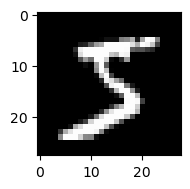

In [33]:
plt.figure(figsize=(2,2))
plt.imshow(X_train[0], cmap="gray")
plt.tight_layout()
plt.show()

In [34]:
X_train = X_train / 255
X_test = X_test / 255

X_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [35]:
model = Sequential([
    Input(shape = (28,28), name = "Input_Layer"),
    Flatten(name = "Flatten_Layer"),
    Dense(units= 32, activation="relu", name= "Hidden_Layer_1"),
    Dense(units= 32, activation="relu", name= "Hidden_Layer_2"),
    Dense(units= 10, activation= "softmax", name="Output_Layer")
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Flatten_Layer (Flatten)         │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_1 (Dense)          │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,506 (103.54 KB)

 Trainable params: 26,506 (103.54 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
model.compile(
    loss = "sparse_categorical_crossentropy",
    optimizer = "adam",
    metrics = ["accuracy"]

)

In [37]:
history = model.fit(
    X_train,
    y_train,
    epochs = 10,
    validation_split = 0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8127 - loss: 0.6464 - val_accuracy: 0.9447 - val_loss: 0.1872
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9472 - loss: 0.1796 - val_accuracy: 0.9582 - val_loss: 0.1503
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9574 - loss: 0.1428 - val_accuracy: 0.9565 - val_loss: 0.1498
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9653 - loss: 0.1154 - val_accuracy: 0.9629 - val_loss: 0.1257
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9688 - loss: 0.1021 - val_accuracy: 0.9607 - val_loss: 0.1282
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9729 - loss: 0.0883 - val_accuracy: 0.9660 - val_loss: 0.1181
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9770 - loss: 0.0783 - val_accuracy: 0.9635 - val_loss: 0.1232
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9781 - loss: 0.0718 - 

In [38]:
y_prob = model.predict(X_test)
y_prob

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([[6.3748797e-09, 2.1060742e-08, 8.5594300e-05, ..., 9.9967062e-01,
        2.3122597e-07, 8.9251336e-07],
       [1.3168005e-11, 4.1889842e-07, 9.9997437e-01, ..., 2.9879429e-14,
        2.5118701e-05, 4.4346185e-16],
       [1.0571699e-06, 9.9856985e-01, 2.1425718e-04, ..., 4.7236215e-04,
        5.1908923e-04, 1.7290376e-05],
       ...,
       [1.3178515e-11, 6.6837785e-10, 3.0370277e-12, ..., 2.1478039e-08,
        3.1105191e-07, 7.5191551e-06],
       [1.3450211e-11, 2.3739370e-11, 1.0203702e-13, ..., 1.4922048e-12,
        6.4886379e-05, 2.1212917e-16],
       [3.4880035e-08, 8.1159868e-10, 2.9944547e-09, ..., 1.7746701e-13,
        2.7873056e-11, 9.3000904e-14]], dtype=float32)

In [39]:
y_pred = y_prob.argmax(axis=1)

In [40]:
cr = classification_report(y_test, y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.97      0.97      1032
           3       0.97      0.97      0.97      1010
           4       0.98      0.96      0.97       982
           5       0.95      0.97      0.96       892
           6       0.98      0.96      0.97       958
           7       0.99      0.95      0.97      1028
           8       0.93      0.97      0.95       974
           9       0.96      0.96      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



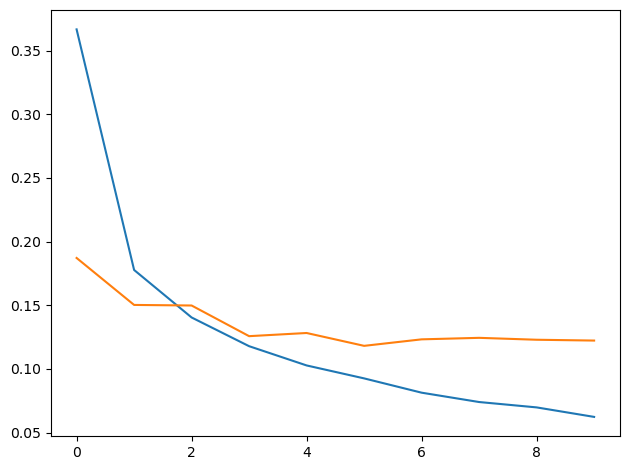

In [41]:

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.tight_layout()
plt.show()

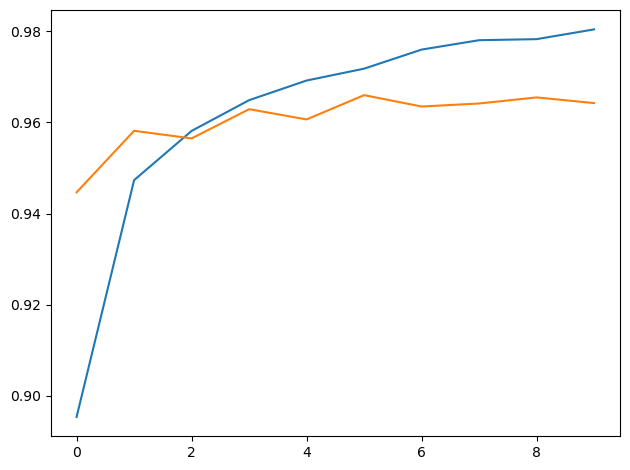

In [42]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.tight_layout()
plt.show()

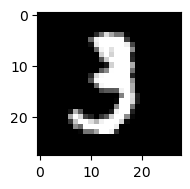

In [43]:
plt.figure(figsize=(2,2))
plt.imshow(X_train[10], cmap="gray")
plt.tight_layout()
plt.show()

In [51]:
model.predict(X_train[[10]]).argmax(axis = 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


array([3], dtype=int64)